In [26]:
import os
import re

'''
r08c12f04p10-ch2sk1fk1fl1_ch2_nucleu_bbx.png   r08c12f04p10-ch2sk1fk1fl1.tiff_cell_count.csv    r08c12f04p10-ch3sk1fk1fl1_ch3_ori.png
r08c12f04p10-ch2sk1fk1fl1_ch2_nucleu_mask.png  r08c12f04p10-ch3sk1fk1fl1_ch3_nucleus_areas.npy
r08c12f04p10-ch2sk1fk1fl1_ch2_ori.png          r08c12f04p10-ch3sk1fk1fl1_ch3_nucleus_areas.png
'''

def find_and_assign_week_paths(base_path):
    for week_folder in os.listdir(base_path):
        week_folder_path = os.path.join(base_path, week_folder)
        if not os.path.isdir(week_folder_path):
            continue
        if 'ch8' in week_folder_path:
            continue

        week_match = re.search(r'week\d+', week_folder, re.IGNORECASE)
        if not week_match:
            continue
        week_label = week_match.group(0).lower()  # e.g., "week1"

        if "Control" in week_folder:
            suffix = 'plc'
        elif "Plate_3" in week_folder:
            suffix = 'pl3'
        elif "Plate_8"  in week_folder:
            suffix = 'pl8'
        else:
            continue

        var_name = f"{week_label}_{suffix}_path"
        globals()[var_name] = week_folder_path

        print(f"{var_name} assigned {week_folder_path}")

# Example usage
base_path = '/hpcgpfs01/scratch/xyu1/'  # ← Replace this with your actual base path
find_and_assign_week_paths(base_path)

week6_plc_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week6
week9_pl8_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_week9_RPE-1_Plate_8_1
week9_plc_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week9
week4_pl3_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_week4_RPE-1_Plate_3_1
week4_plc_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week4
week3_plc_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week3
week2_pl8_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_week2_RPE-1_Plate_8_1
week3_pl3_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_week3_RPE-1_Plate_3_1
week5_pl3_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_week5_RPE-1_Plate_3_1
week4_pl8_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_week4_RPE-1_Plate_8_1
week6_pl8_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_week6_RPE-1_Plate_8_1
week1_pl8_path assigned /hpcgpfs01/scratch/xyu1/ch2_3_new_week1_RPE-1_Plate_8_1
week7_pl8_path assigned /hpcgpfs01/scrat

In [17]:
import os
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

#ch3_nucleus = '-ch3sk1fk1fl1_ch3_nucleus_areas.npy'
#ch2_mask = '-ch2sk1fk1fl1_ch2_nucleu_mask.png'
#cell_count = '-ch2sk1fk1fl1.tiff_cell_count.csv'

ch3_nucleus = '-ch3sk1fk1fl1_ch3_nucleus_areas.npy'
ch8_nucleus = '-ch8sk1fk1fl1_ch8_nucleus_areas.npy'
ch2_mask = '-ch2sk1fk1fl1_ch2_nucleu_mask.png'
cell_count = '-ch2sk1fk1fl1_cell_count.csv'

class CellPaintBase(Dataset):
    def __init__(self, root_directory, feat_type='pixel_average', transform=None):
        """
        Args:
            root_directory (str): Root path to the cell paint data.
            dosage_directory (dict): A mapping from directory names to dosage values.
            transform (callable, optional): Optional transform to be applied on the image.
        """
        self.root_directory = root_directory
        self.transform = transform
        self.feat_type = feat_type
        # List to store each record as a dictionary
        self.data = []
        temp_name_set = set()
        # Walk through the directory structure and gather file paths

        
        for root, _, files in os.walk(root_directory):
            for file in files:
                name, ext = os.path.splitext(file)
                
                if not file.endswith('nucleus_areas.png'):
                    continue

                

                # Build file paths
                run_name = name[:9]  # r01c02f03

                if run_name in temp_name_set:
                    continue
                else:
                    temp_name_set.add(run_name)

                
                ch3_nucleus_areas_list = []
                ch8_nucleus_areas_list = []
                ch2_nucleu_mask_list = []
                cell_count_path_list = []

                for p in range(1, 16):
                    p2d = f'p{p:02d}'
                    ch3_nucleus_areas_list.append(
                        os.path.join(root, run_name + p2d+ ch3_nucleus)
                    )
                    ch8_nucleus_areas_list.append(
                        os.path.join(root+'_ch8', run_name + p2d+ ch8_nucleus)   # this is designed for week3-5 ch8
                    )
                    ch2_nucleu_mask_list.append(
                        os.path.join(root, run_name + p2d + ch2_mask)
                    )
                    cell_count_path_list.append(
                        os.path.join(root, run_name + p2d + cell_count)
                    )
                
                #    feat_image_path = os.path.join(root, run_name + feat_ext)
                #    seg_image_path = os.path.join(root, run_name + seg_ext)
                #    csv_path = os.path.join(root, run_name+csv_ext)
                # csv_path = os.path.join(root, name + '_cell_count.csv')
                # csv_data_path = os.path.join(root, name + '_data.csv')
                
                # Create a record dictionary
                record = {
                    'ch3_nucleus': ch3_nucleus_areas_list,
                    'ch8_nucleus': ch8_nucleus_areas_list, 
                    'run_name': run_name,
                    'ch2_mask': ch2_nucleu_mask_list, 
                    'cell_count_path': cell_count_path_list,
                }
                
                # Load the CSV file to get the cell count (assumes the count is in the first row)
                try:
                    cell_count_list = []
                    for csv_path in cell_count_path_list:
                        df = pd.read_csv(csv_path)
                        cell_count_list.append(df['cell_count'][0])
                    record['cell_count'] = cell_count_list
                except Exception as e:
                    print(f"Error reading CSV file {csv_path}: {e}")
                    continue  # Skip this record if there's an issue reading the CSV
                
                # Determine dosage by checking directory names in the relative path
                
                
                self.data.append(record)
    
    def __len__(self):
        return len(self.data)
    
    def feat_func(self, record, type='rpe_images', ch=3):

        if type == 'pixel_average':
            img_array = np.load(record['feat_image_path'])

            feature = img_array[img_array>0].mean()
        elif type == 'depth_maximize_pixel_avg':
            img_list = []
            if ch == 3:
                for data_path in record['ch3_nucleus']:
                    img_array = np.load(data_path)
                    img_list.append(img_array)
            elif ch == 8:
                for data_path in record['ch8_nucleus']:
                    img_array = np.load(data_path)
                    img_list.append(img_array)
            stacked = np.stack(img_list)
            max_image = np.max(stacked, axis=0)
            feature = max_image[max_image>0].sum()
                
        else:
            raise NotImplementedError()
        
        return feature
    
    def __getitem__(self, idx):
        record = self.data[idx]
        
        feature = self.feat_func(record, self.feat_type)
        record['feature'] = feature

        feature8 = self.feat_func(record, self.feat_type, ch=8)
        record['feature8'] = feature8
        
        return record


#maximize over p value, run_name is r, c, f values

In [18]:
exp_setting = {}

plate3_exp = {
    'rad_2': {'r': [7, 8], 'c': [1, 2, 3, 4]},
    'rad_1': {'r': [1, 2, 3, 4], 'c': [1, 2]},
    'rad_0.1': {'r':[1, 2, 3, 4], 'c': [6, 7]},
    'rad_0.01': {'r':[7, 8], 'c': [9, 10, 11, 12]},
    'rad_0.001': {'r':[1, 2, 3, 4], 'c': [11, 12]},
}
plate8_exp_green = {
    'rad_2': {'r': [7], 'c': [3, 4]},
    'rad_1': {'r': [4], 'c': [1, 2]},
    'rad_0.1': {'r':[4], 'c': [6, 7]},
    'rad_0.01': {'r':[8], 'c': [11, 12]},
    'rad_0.001': {'r':[4], 'c': [11, 12]},
}
plate8_exp_red = {
    'rad_2': {'r': [8], 'c': [3, 4]},
    'rad_1': {'r': [3], 'c': [1, 2]},
    'rad_0.1': {'r':[3], 'c': [6, 7]},
    'rad_0.01': {'r':[7], 'c': [11, 12]},
    'rad_0.001': {'r':[3], 'c': [11, 12]},
}
plate8_exp_yellow = {
    'rad_2': {'r': [7, 8], 'c': [1, 2, ]},
    'rad_1': {'r': [1, 2,], 'c': [1, 2]},
    'rad_0.1': {'r':[1, 2,], 'c': [6, 7]},
    'rad_0.01': {'r':[7, 8], 'c': [9, 10,]},
    'rad_0.001': {'r':[1, 2,], 'c': [11, 12]},
}

platec_exp_yellow = {
    '0': {'r':[1, 2], 'c': [4, 5]}, 
    'DMSO':{'r':[5], 'c':[4, 5]},
    'E100': {'r':[7], 'c':[4, 5]}, 
}

platec_exp_red = {
    '0': {'r':[3, 4], 'c': [4, 5]}, 
    'DMSO':{'r':[6], 'c':[4, 5]},
    'E100': {'r':[8], 'c':[4, 5]}, 
}

platec_exp_green = {
    '0': {'r':[5, 6], 'c': [3, 6]}, 
    'DMSO':{'r':[7], 'c':[3, 6]},
    'E100': {'r':[8], 'c':[3, 6]}, 
}

dye_label = {
    'plate3_exp': None, 
    'plate8_exp_green': 'caspase on ch3',
    'plate8_exp_red':'caspase on ch3 and h2ax on ch8',
    'plate8_exp_yellow': 'h2ax on ch3',
    'platec_exp_green': 'caspase on ch3',
    'platec_exp_red':'caspase on ch3 and h2ax on ch8',
    'platec_exp_yellow': 'h2ax on ch3',
}

dye_label2 = {
    'plate3_exp': 'normal ch8', 
    'plate8_exp_green': 'normal ch8',
    'plate8_exp_red':'h2ax on ch8',
    'plate8_exp_yellow': 'normal ch8',
    'platec_exp_green': 'normal ch8',
    'platec_exp_red':'h2ax on ch8',
    'platec_exp_yellow': 'normal ch8',
}

exp_setting['plate3_exp'] = plate3_exp
exp_setting['plate8_exp_green'] = plate8_exp_green
exp_setting['plate8_exp_red'] = plate8_exp_red
exp_setting['plate8_exp_yellow'] = plate8_exp_yellow

exp_setting['platec_exp_yellow'] = platec_exp_yellow
exp_setting['platec_exp_red'] = platec_exp_red
exp_setting['platec_exp_green'] = platec_exp_green

In [22]:
week_name = 'week8_pl8_path'
root_directory = locals()[week_name]

feat_type = 'depth_maximize_pixel_avg' 

# Example transform using torchvision
from torchvision import transforms
# transform = transforms.Compose([
# transforms.Resize((256, 256)),
# transforms.ToTensor()
# ])

dataset = CellPaintBase(root_directory=root_directory, feat_type=feat_type)
print('dataset len')
len(dataset)

dataset len


180

Loaded existing data_dict.


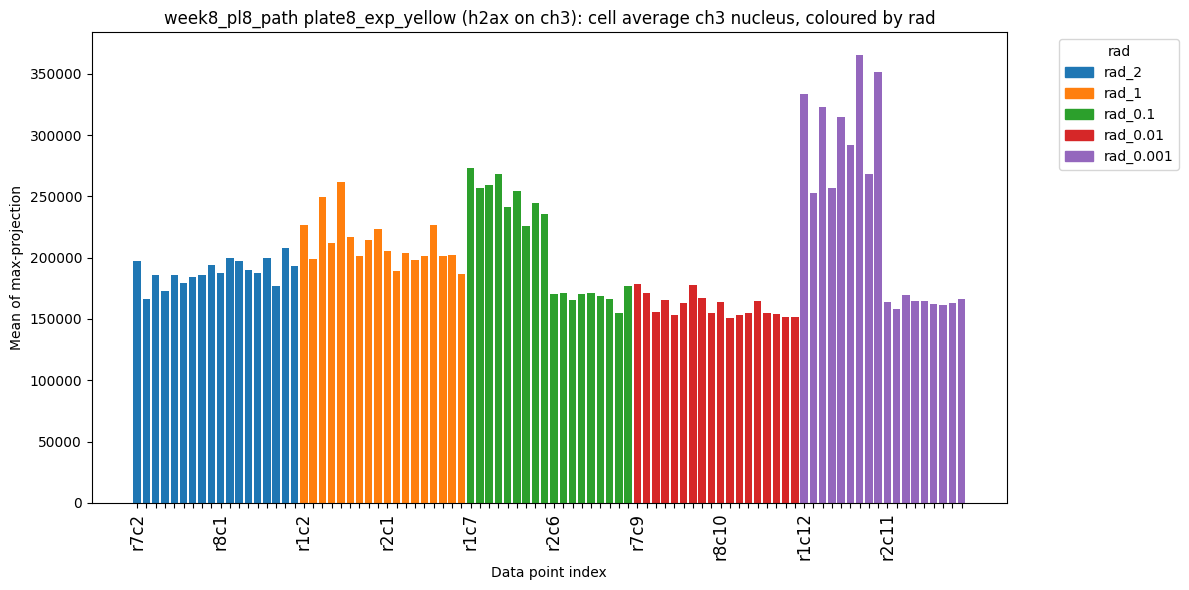

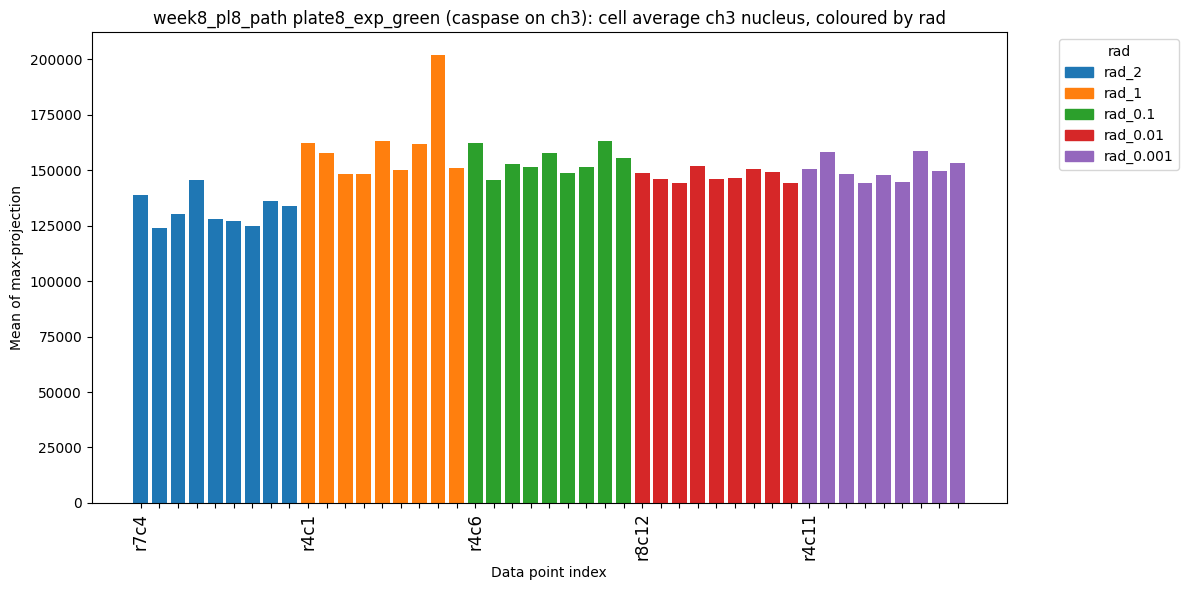

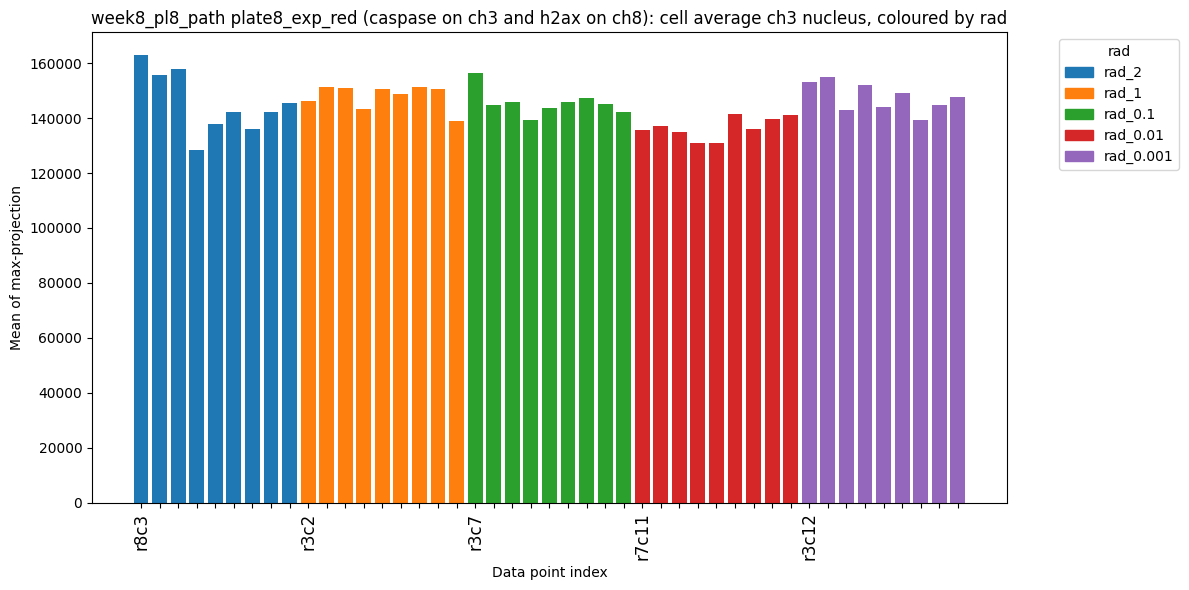

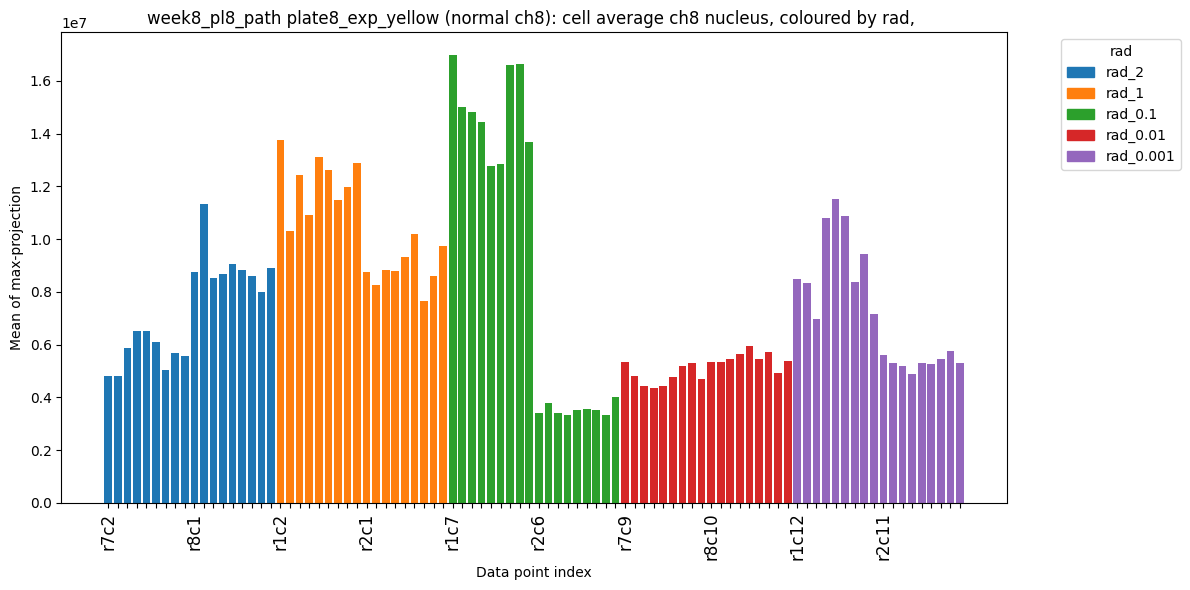

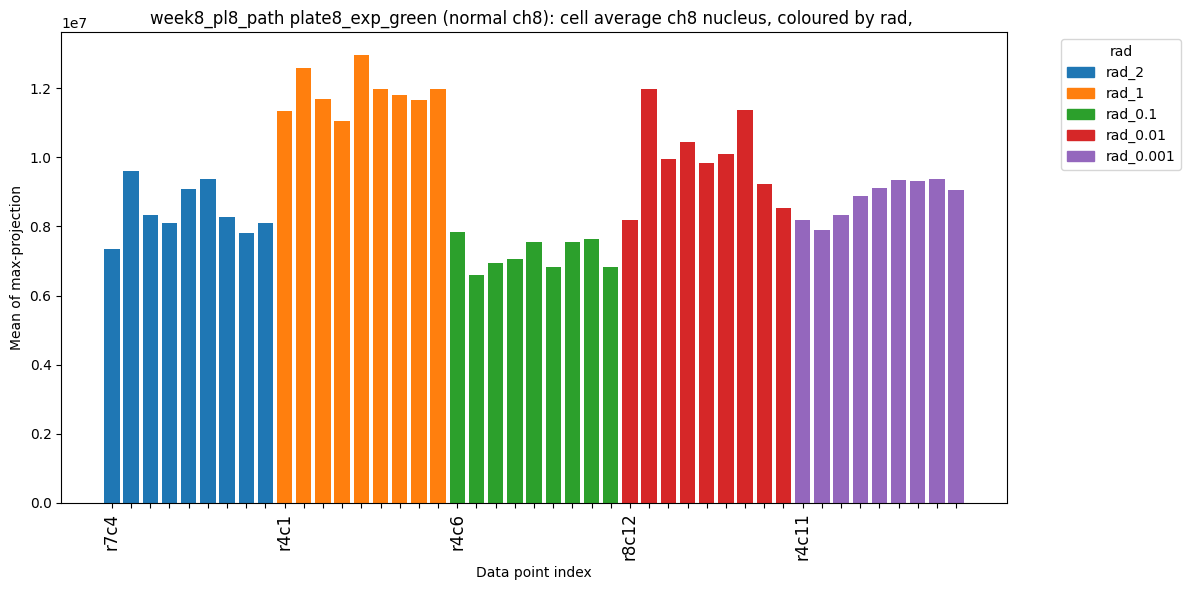

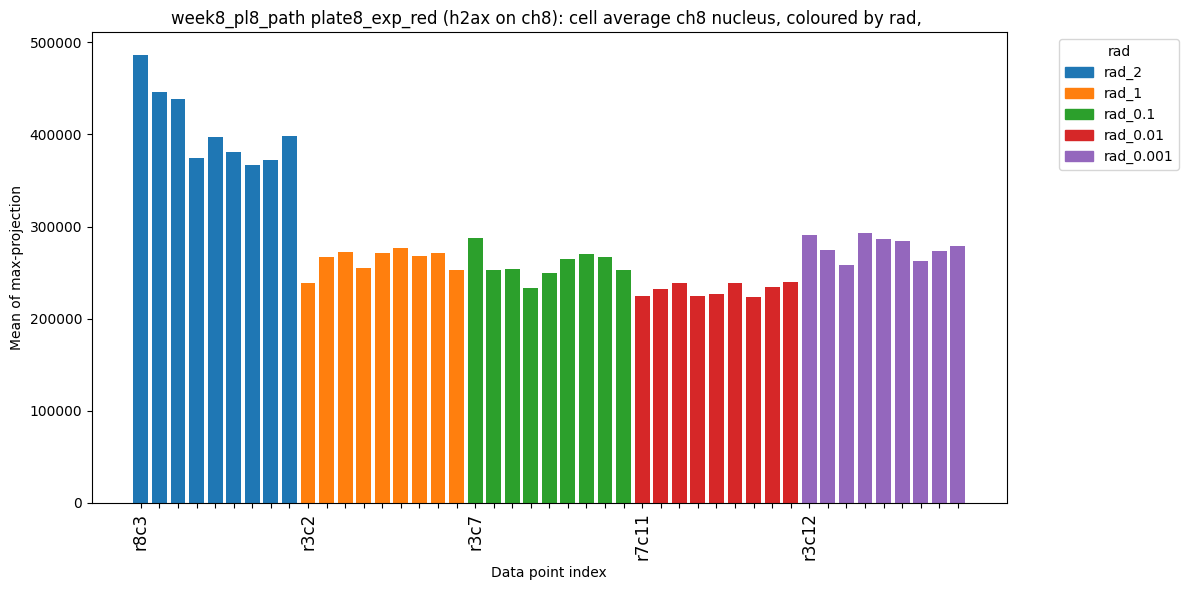

In [25]:
import os
import pickle
from tqdm import tqdm
file_path = f'{week_name}_dataset.pkl'

if os.path.exists(file_path):
    # Load existing data_dict
    with open(file_path, 'rb') as f:
        data_dict = pickle.load(f)
    print("Loaded existing data_dict.")
else:
    # Create and populate data_dict
    data_dict = {}
    for data in tqdm(dataset):
        run_name = data['run_name']
        data_dict[run_name] = data  # Ensure `data` is JSON-serializable

    # Save it
    with open(file_path, 'wb') as f:
        pickle.dump(data_dict, f)
    print("Created and saved data_dict.")


import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as mpatches

# ─── DRAW FIGURES ───────────────────────────────────────────────────────────────

if 'pl8' in week_name:
    exp_name_list = ['plate8_exp_yellow', 'plate8_exp_green', 'plate8_exp_red', ]
elif 'plc' in week_name:
    exp_name_list = ['platec_exp_yellow', 'platec_exp_green', 'platec_exp_red', ]
elif 'pl3' in week_name:
    exp_name_list = ['plate3_exp']

for exp_name in exp_name_list:
    ch        = '3'
    plate_exp = exp_setting[exp_name]
    rad_keys  = list(plate_exp.keys())
    
    title_name = f"{week_name} {exp_name} ({dye_label[exp_name]}): cell average ch3 nucleus, coloured by rad"
    
    # ─── STORAGE FOR RESULTS ──────────────────────────────────────────────────────
    all_values       = []
    all_rad_keys     = []
    all_rc_keys      = []
    image_means_by_r = {rad: [] for rad in rad_keys}

    # ─── SINGLE LOOP: LOAD ONCE, COMPUTE TWICE ────────────────────────────────────
    for rad in rad_keys:
        if rad == 'dye_label':
            continue
        for r in plate_exp[rad]['r']:
            for c in plate_exp[rad]['c']:
                for f in range(1, 10):
                    stack = []
                    sample_name = f"r{r:02d}c{c:02d}f{f:02d}"
                    if sample_name in data_dict:
                        feature = data_dict[sample_name]['feature']/np.array(data_dict[sample_name]['cell_count']).mean()
        
                        all_values.append(feature)
                        all_rad_keys.append(rad)
                        all_rc_keys.append(f"r{r}c{c}")
                        image_means_by_r[rad].append(feature)

    # ─── PREPARE COLORS & AGGREGATES ───────────────────────────────────────────────
    cmap       = plt.get_cmap('tab10')
    colour_map = {rad: cmap(i) for i, rad in enumerate(rad_keys)}
    bar_colors = [colour_map[rad] for rad in all_rad_keys]
    
    labels = rad_keys
    means  = [np.mean(image_means_by_r[r]) for r in labels]
    stds   = [np.std (image_means_by_r[r]) for r in labels]
    
    # ─── FIGURE 1: ALL (r,c,f) BARS, ONE LABEL PER GROUP ─────────────────────────
    plt.figure(figsize=(12, 6))
    x = np.arange(len(all_values))
    plt.bar(x, all_values, color=bar_colors)
    plt.title(title_name)
    plt.xlabel("Data point index")
    plt.ylabel("Mean of max-projection")
    
    # build tick labels: only the first bar of each r{r}c{c} group gets its label
    tick_labels = []
    prev = None
    for lab in all_rc_keys:
        if lab != prev:
            tick_labels.append(lab)
            prev = lab
        else:
            tick_labels.append('')
    
    plt.xticks(x, tick_labels, rotation=90, fontsize=12)

    # Legend for rad groups
    patches = [mpatches.Patch(color=colour_map[rad], label=rad) for rad in rad_keys]
    plt.legend(handles=patches, title="rad", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.tight_layout()
    plt.savefig(f"./draw_result/{title_name}.png")
    plt.show()

# red channel 8
for exp_name in exp_name_list:
    if 'red' not in exp_name:
        pass
    plate_exp = exp_setting[exp_name]
    rad_keys  = list(plate_exp.keys())
    
    title_name = f"{week_name} {exp_name} ({dye_label2[exp_name]}): cell average ch8 nucleus, coloured by rad, "
    
    # ─── STORAGE FOR RESULTS ──────────────────────────────────────────────────────
    all_values       = []
    all_rad_keys     = []
    all_rc_keys      = []
    image_means_by_r = {rad: [] for rad in rad_keys}

    # ─── SINGLE LOOP: LOAD ONCE, COMPUTE TWICE ────────────────────────────────────
    for rad in rad_keys:
        if rad == 'dye_label':
            continue
        for r in plate_exp[rad]['r']:
            for c in plate_exp[rad]['c']:
                for f in range(1, 10):
                    stack = []
                    sample_name = f"r{r:02d}c{c:02d}f{f:02d}"
                    if sample_name in data_dict:
                        feature = data_dict[sample_name]['feature8']/np.array(data_dict[sample_name]['cell_count']).mean()
        
                        all_values.append(feature)
                        all_rad_keys.append(rad)
                        all_rc_keys.append(f"r{r}c{c}")
                        image_means_by_r[rad].append(feature)

    # ─── PREPARE COLORS & AGGREGATES ───────────────────────────────────────────────
    cmap       = plt.get_cmap('tab10')
    colour_map = {rad: cmap(i) for i, rad in enumerate(rad_keys)}
    bar_colors = [colour_map[rad] for rad in all_rad_keys]
    
    labels = rad_keys
    means  = [np.mean(image_means_by_r[r]) for r in labels]
    stds   = [np.std (image_means_by_r[r]) for r in labels]
    
    # ─── FIGURE 1: ALL (r,c,f) BARS, ONE LABEL PER GROUP ─────────────────────────
    plt.figure(figsize=(12, 6))
    x = np.arange(len(all_values))
    plt.bar(x, all_values, color=bar_colors)
    plt.title(title_name)
    plt.xlabel("Data point index")
    plt.ylabel("Mean of max-projection")
    
    # build tick labels: only the first bar of each r{r}c{c} group gets its label
    tick_labels = []
    prev = None
    for lab in all_rc_keys:
        if lab != prev:
            tick_labels.append(lab)
            prev = lab
        else:
            tick_labels.append('')
    
    plt.xticks(x, tick_labels, rotation=90, fontsize=12)

    # Legend for rad groups
    patches = [mpatches.Patch(color=colour_map[rad], label=rad) for rad in rad_keys]
    plt.legend(handles=patches, title="rad", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.tight_layout()
    plt.savefig(f"./draw_result/{title_name}.png")
    plt.show()


Loaded existing data_dict.


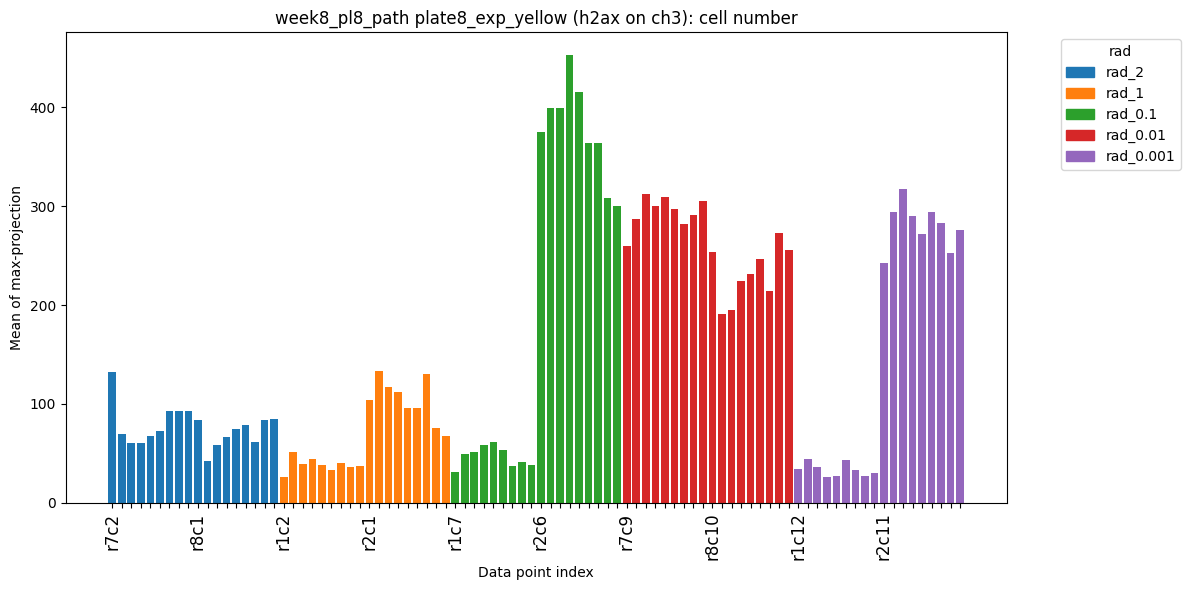

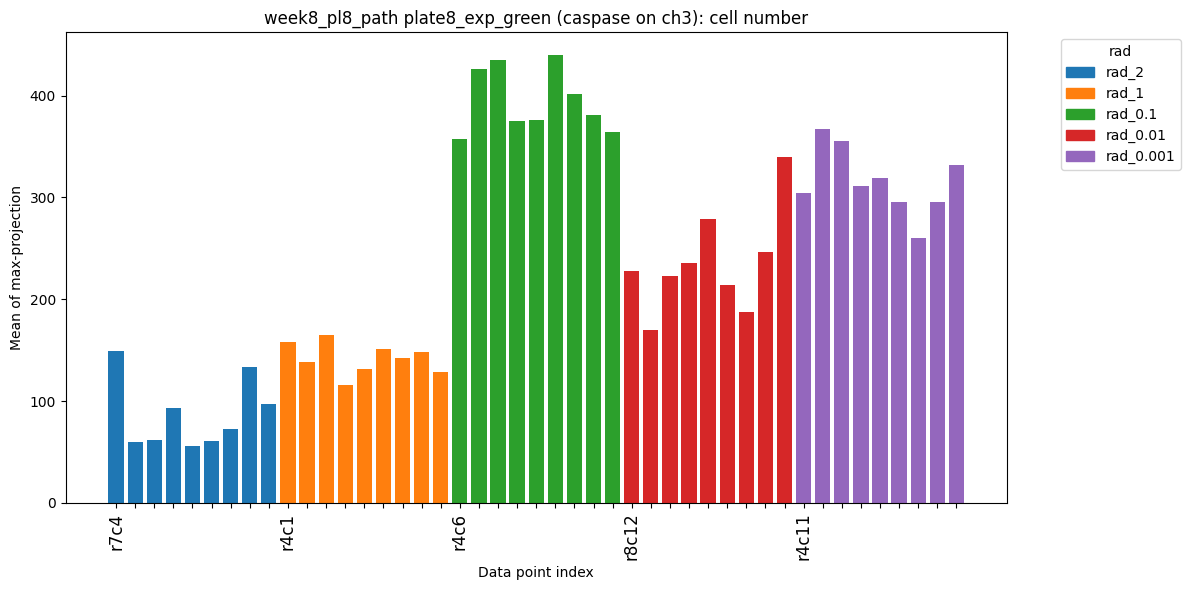

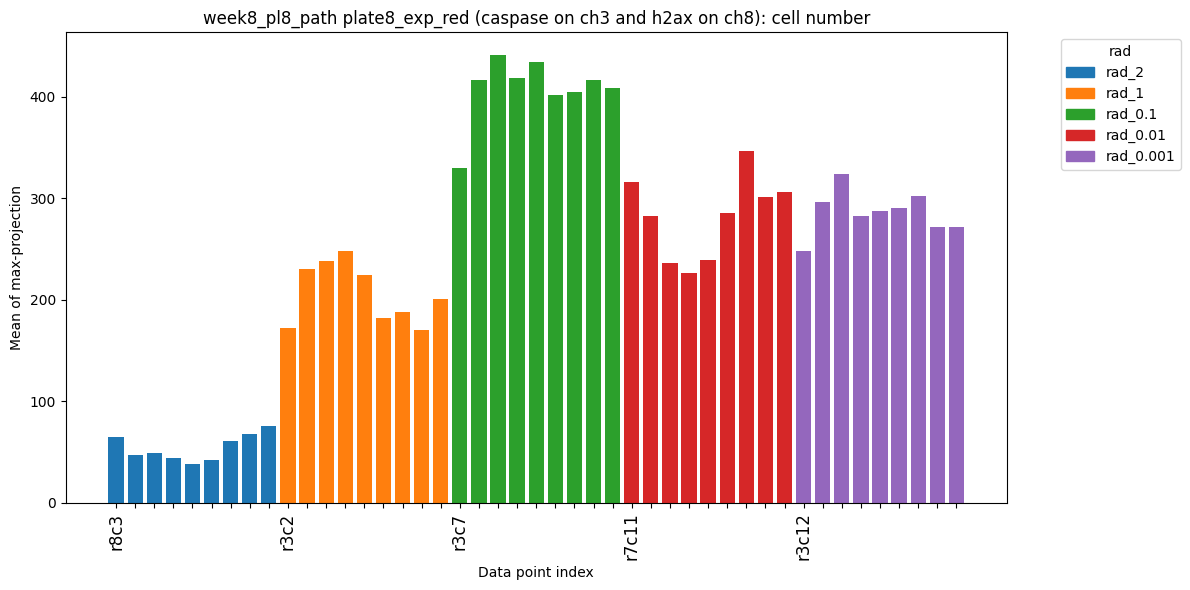

In [24]:
import os
import pickle
from tqdm import tqdm
file_path = f'{week_name}_dataset.pkl'

if os.path.exists(file_path):
    # Load existing data_dict
    with open(file_path, 'rb') as f:
        data_dict = pickle.load(f)
    print("Loaded existing data_dict.")
else:
    # Create and populate data_dict
    data_dict = {}
    for data in tqdm(dataset):
        run_name = data['run_name']
        data_dict[run_name] = data  # Ensure `data` is JSON-serializable

    # Save it
    with open(file_path, 'wb') as f:
        pickle.dump(data_dict, f)
    print("Created and saved data_dict.")


import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as mpatches

# ─── DRAW FIGURES ───────────────────────────────────────────────────────────────

if 'pl8' in week_name:
    exp_name_list = ['plate8_exp_yellow', 'plate8_exp_green', 'plate8_exp_red', ]
elif 'plc' in week_name:
    exp_name_list = ['platec_exp_yellow', 'platec_exp_green', 'platec_exp_red', ]
elif 'pl3' in week_name:
    exp_name_list = ['plate3_exp']

for exp_name in exp_name_list:
    ch        = '3'
    plate_exp = exp_setting[exp_name]
    rad_keys  = list(plate_exp.keys())
    
    title_name = f"{week_name} {exp_name} ({dye_label[exp_name]}): cell number"
    
    # ─── STORAGE FOR RESULTS ──────────────────────────────────────────────────────
    all_values       = []
    all_rad_keys     = []
    all_rc_keys      = []
    image_means_by_r = {rad: [] for rad in rad_keys}

    # ─── SINGLE LOOP: LOAD ONCE, COMPUTE TWICE ────────────────────────────────────
    for rad in rad_keys:
        if rad == 'dye_label':
            continue
        for r in plate_exp[rad]['r']:
            for c in plate_exp[rad]['c']:
                for f in range(1, 10):
                    stack = []
                    sample_name = f"r{r:02d}c{c:02d}f{f:02d}"
                    if sample_name in data_dict:
                        feature = np.array(data_dict[sample_name]['cell_count']).mean()
        
                        all_values.append(feature)
                        all_rad_keys.append(rad)
                        all_rc_keys.append(f"r{r}c{c}")
                        image_means_by_r[rad].append(feature)

    # ─── PREPARE COLORS & AGGREGATES ───────────────────────────────────────────────
    cmap       = plt.get_cmap('tab10')
    colour_map = {rad: cmap(i) for i, rad in enumerate(rad_keys)}
    bar_colors = [colour_map[rad] for rad in all_rad_keys]
    
    labels = rad_keys
    means  = [np.mean(image_means_by_r[r]) for r in labels]
    stds   = [np.std (image_means_by_r[r]) for r in labels]
    
    # ─── FIGURE 1: ALL (r,c,f) BARS, ONE LABEL PER GROUP ─────────────────────────
    plt.figure(figsize=(12, 6))
    x = np.arange(len(all_values))
    plt.bar(x, all_values, color=bar_colors)
    plt.title(title_name)
    plt.xlabel("Data point index")
    plt.ylabel("Mean of max-projection")
    
    # build tick labels: only the first bar of each r{r}c{c} group gets its label
    tick_labels = []
    prev = None
    for lab in all_rc_keys:
        if lab != prev:
            tick_labels.append(lab)
            prev = lab
        else:
            tick_labels.append('')
    
    plt.xticks(x, tick_labels, rotation=90, fontsize=12)

    # Legend for rad groups
    patches = [mpatches.Patch(color=colour_map[rad], label=rad) for rad in rad_keys]
    plt.legend(handles=patches, title="rad", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.tight_layout()
    plt.savefig(f"./draw_result/{title_name}.png")
    plt.show()


In [20]:
image_means_by_r

{'0': [], 'DMSO': [], 'E100': []}

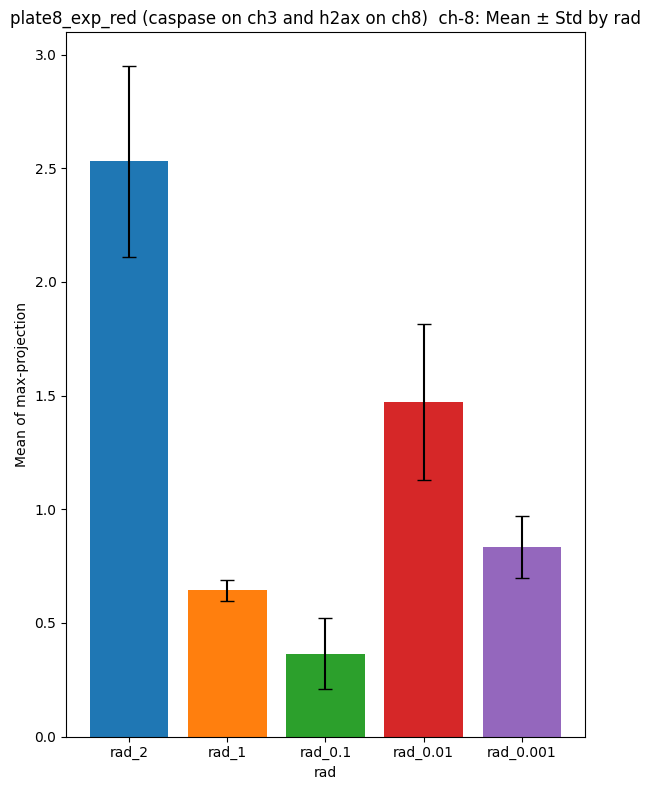

In [22]:
# ─── FIGURE 2: MEAN ± STD PER rad ─────────────────────────────────────────────
plt.figure(figsize=(6, 8))
x2 = np.arange(len(labels))
plt.bar(x2, means, yerr=stds, capsize=5, color=[colour_map[r] for r in labels])
plt.title(f"{exp_name} ({dye_label[exp_name]})  ch-{ch}: Mean ± Std by rad")
plt.xlabel("rad")
plt.ylabel("Mean of max-projection")
plt.xticks(x2, labels)

plt.tight_layout()
plt.show()

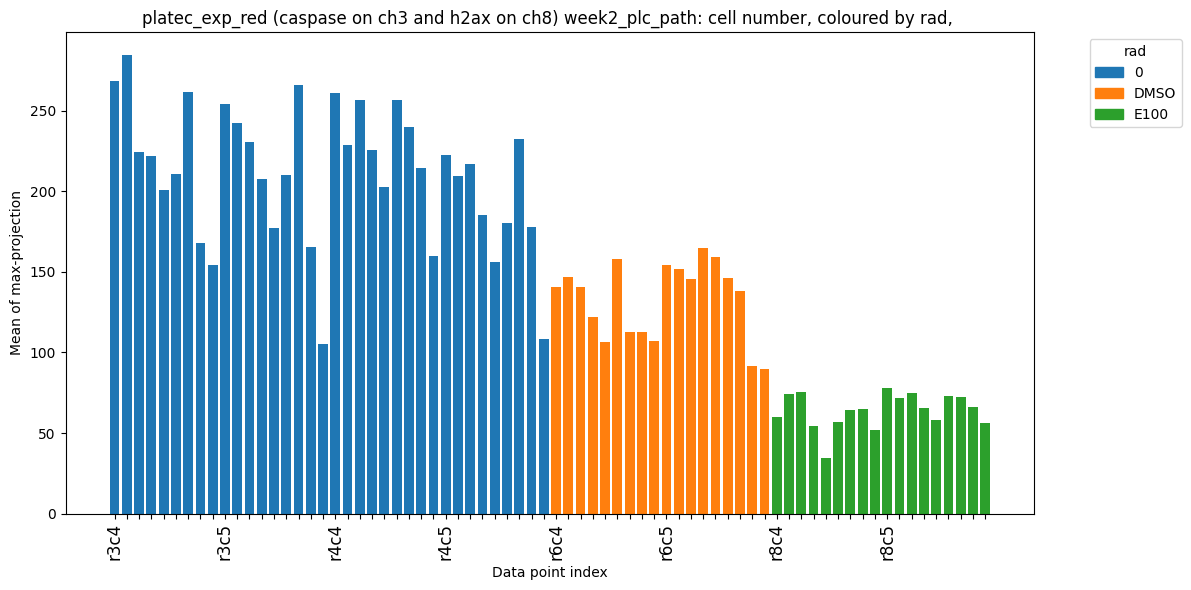

In [117]:


title_name = f"{exp_name} ({dye_label[exp_name]}) {week_name}: cell number, coloured by rad, "

# ─── STORAGE FOR RESULTS ──────────────────────────────────────────────────────
all_values       = []
all_rad_keys     = []
all_rc_keys      = []
image_means_by_r = {rad: [] for rad in rad_keys}

# ─── SINGLE LOOP: LOAD ONCE, COMPUTE TWICE ────────────────────────────────────
for rad in rad_keys:
    if rad == 'dye_label':
        continue
    for r in plate_exp[rad]['r']:
        for c in plate_exp[rad]['c']:
            for f in range(1, 10):
                stack = []
                sample_name = f"r{r:02d}c{c:02d}f{f:02d}"
                if sample_name in data_dict:
                    feature = np.array(data_dict[sample_name]['cell_count']).mean()
    
                    all_values.append(feature)
                    all_rad_keys.append(rad)
                    all_rc_keys.append(f"r{r}c{c}")
                    image_means_by_r[rad].append(feature)

# ─── PREPARE COLORS & AGGREGATES ───────────────────────────────────────────────
cmap       = plt.get_cmap('tab10')
colour_map = {rad: cmap(i) for i, rad in enumerate(rad_keys)}
bar_colors = [colour_map[rad] for rad in all_rad_keys]

labels = rad_keys
means  = [np.mean(image_means_by_r[r]) for r in labels]
stds   = [np.std (image_means_by_r[r]) for r in labels]

# ─── FIGURE 1: ALL (r,c,f) BARS, ONE LABEL PER GROUP ─────────────────────────
plt.figure(figsize=(12, 6))
x = np.arange(len(all_values))
plt.bar(x, all_values, color=bar_colors)
plt.title(title_name)
plt.xlabel("Data point index")
plt.ylabel("Mean of max-projection")

# build tick labels: only the first bar of each r{r}c{c} group gets its label
tick_labels = []
prev = None
for lab in all_rc_keys:
    if lab != prev:
        tick_labels.append(lab)
        prev = lab
    else:
        tick_labels.append('')

plt.xticks(x, tick_labels, rotation=90, fontsize=12)

# Legend for rad groups
patches = [mpatches.Patch(color=colour_map[rad], label=rad) for rad in rad_keys]
plt.legend(handles=patches, title="rad", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [43]:
sample

{'ch3_nucleus': ['/hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week2/r02c01f02p01-ch3sk1fk1fl1_ch3_nucleus_areas.npy',
  '/hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week2/r02c01f02p02-ch3sk1fk1fl1_ch3_nucleus_areas.npy',
  '/hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week2/r02c01f02p03-ch3sk1fk1fl1_ch3_nucleus_areas.npy',
  '/hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week2/r02c01f02p04-ch3sk1fk1fl1_ch3_nucleus_areas.npy',
  '/hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week2/r02c01f02p05-ch3sk1fk1fl1_ch3_nucleus_areas.npy',
  '/hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week2/r02c01f02p06-ch3sk1fk1fl1_ch3_nucleus_areas.npy',
  '/hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week2/r02c01f02p07-ch3sk1fk1fl1_ch3_nucleus_areas.npy',
  '/hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week2/r02c01f02p08-ch3sk1fk1fl1_ch3_nucleus_areas.npy',
  '/hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week2/r02c01f02p09-ch3sk1fk1fl1_ch3_nucleus_areas.npy',
  '/

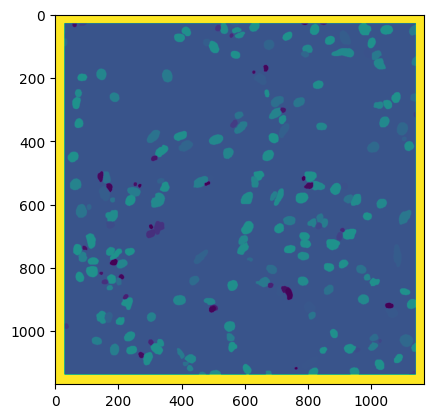

In [54]:
from PIL import Image

mask = Image.open(sample['ch2_mask'][0])
plt.imshow(np.array(mask)[..., 2])

In [47]:
np.load(sample['ch3_nucleus'][0]).shape

(1080, 1080)

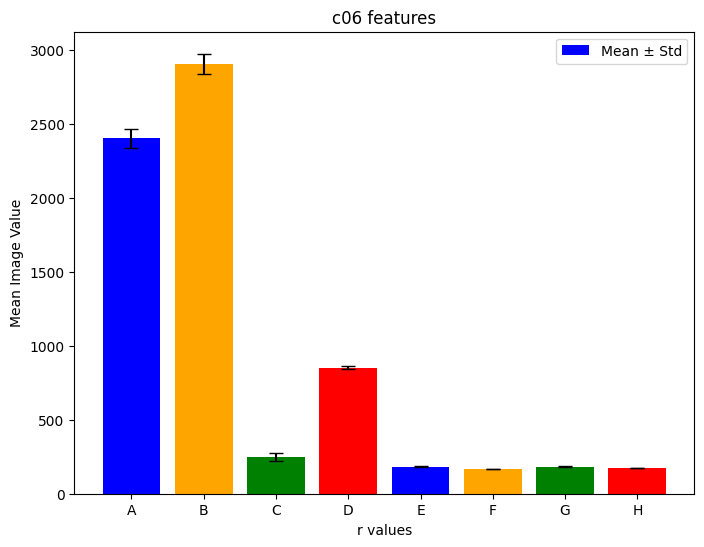

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as mpatches


def feature_func(sample):
    
    

# ─── PARAMETERS ───────────────────────────────────────────────────────────────
dir_path  = week2_plc_path       # your base folder
exp_name  = 'platec_exp_red'
ch        = '8'
plate_exp = exp_setting[exp_name]
rad_keys  = list(plate_exp.keys())

title_name = f"{exp_name} ({dye_label[exp_name]}): cell average ch3 nucleus, coloured by rad, "

# ─── STORAGE FOR RESULTS ──────────────────────────────────────────────────────
all_values       = []
all_rad_keys     = []
all_rc_keys      = []
image_means_by_r = {rad: [] for rad in rad_keys}

# ─── SINGLE LOOP: LOAD ONCE, COMPUTE TWICE ────────────────────────────────────
for rad in rad_keys:
    if rad == 'dye_label':
        continue
    for r in plate_exp[rad]['r']:
        for c in plate_exp[rad]['c']:
            for f in range(1, 10):
                stack = []
                sample_name = f"r{r:02d}c{c:02d}f{f:02d}"
                if sample_name in data_dict:
                    feature = data_dict[sample_name]['feature']/np.array(data_dict[sample_name]['cell_count']).mean()
    
                    all_values.append(feature)
                    all_rad_keys.append(rad)
                    all_rc_keys.append(f"r{r}c{c}")
                    image_means_by_r[rad].append(feature)

# ─── PREPARE COLORS & AGGREGATES ───────────────────────────────────────────────
cmap       = plt.get_cmap('tab10')
colour_map = {rad: cmap(i) for i, rad in enumerate(rad_keys)}
bar_colors = [colour_map[rad] for rad in all_rad_keys]

labels = rad_keys
means  = [np.mean(image_means_by_r[r]) for r in labels]
stds   = [np.std (image_means_by_r[r]) for r in labels]

# ─── FIGURE 1: ALL (r,c,f) BARS, ONE LABEL PER GROUP ─────────────────────────
plt.figure(figsize=(12, 6))
x = np.arange(len(all_values))
plt.bar(x, all_values, color=bar_colors)
plt.title(title_name)
plt.xlabel("Data point index")
plt.ylabel("Mean of max-projection")

# build tick labels: only the first bar of each r{r}c{c} group gets its label
tick_labels = []
prev = None
for lab in all_rc_keys:
    if lab != prev:
        tick_labels.append(lab)
        prev = lab
    else:
        tick_labels.append('')

plt.xticks(x, tick_labels, rotation=90, fontsize=12)

# Legend for rad groups
patches = [mpatches.Patch(color=colour_map[rad], label=rad) for rad in rad_keys]
plt.legend(handles=patches, title="rad", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


### previous code 

In [ ]:
## image list result cell count

# Initialize a dictionary to store the means of the images for each r
image_means_by_r = {}
c = '12'
# Iterate through the values of r
for r in ['01', '02', '03', '04', '05', '06', '07', '08']:
    image_means = []  # Initialize a list to store the means for the current r
    
    # Iterate through the values of f
    for f in range(1, 10):  # f takes values from '01' to '09'
        # Iterate through the images
        for p in ['01']:  # Assuming there are 5 images (p01 to p05)
            # Load the TIFF image
            run_name = f'r{r}c{c}f{f:02d}'
            if run_name in sample_list:
                feature = sample_list[run_name]['feature']
                image_means.append(feature)
            else:
                # print('no', run_name)
                pass
    
    # Store the means for the current r
    image_means_by_r[r] = image_means

# Calculate the mean and standard deviation for each r
mean_std_by_r = {r: (np.mean(means), np.std(means)) for r, means in image_means_by_r.items()}

# Plot the mean and standard deviation for each r
labels = list(mean_std_by_r.keys())
means = [mean_std_by_r[r][0] for r in labels]
stds = [mean_std_by_r[r][1] for r in labels]

x = range(len(labels))  # X-axis positions

plt.figure(figsize=(8, 6))
plt.bar(x, means, yerr=stds, capsize=5, color=['blue', 'orange', 'green', 'red'])
plt.xticks(x, labels)
plt.xlabel('r values')
plt.ylabel('Mean Image Value')
plt.title(f'c{c} features')
plt.legend(['Mean ± Std'])
plt.show()

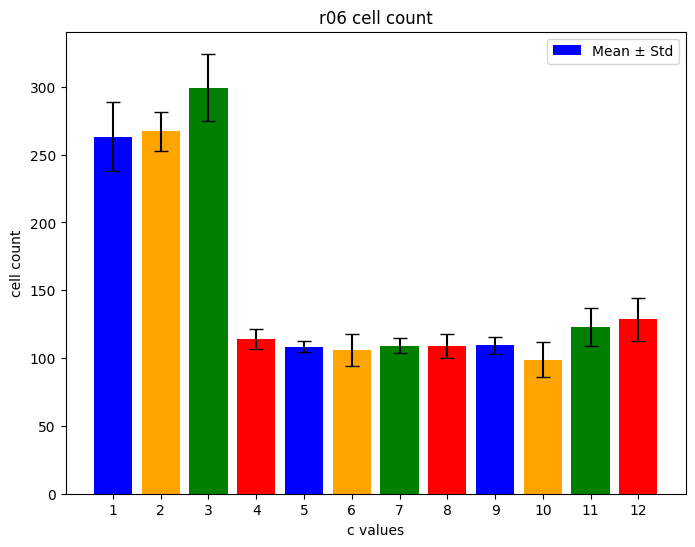

In [22]:
# Initialize a dictionary to store the means of the images for each r

from matplotlib import pyplot as plt
image_means_by_c = {}
r = '06'
# Iterate through the values of r
for c in range(1, 13):
    image_means = []  # Initialize a list to store the means for the current r
    
    # Iterate through the values of f
    for f in range(1, 10):  # f takes values from '01' to '09'
        # Iterate through the images
        for p in range(1, 16):  # Assuming there are 5 images (p01 to p05)
            # Load the TIFF image
            run_name = f'r{r}c{c:02d}f{f:02d}p{p:02d}'
            if run_name in image_list:
                cell_count = image_list[run_name]['cell_count']
                image_means.append(cell_count)
            else:
                # print('no', run_name)
                pass
    
    # Store the means for the current r
    image_means_by_c[c] = image_means

# Calculate the mean and standard deviation for each r
mean_std_by_c = {c: (np.mean(means), np.std(means)) for c, means in image_means_by_c.items()}

# Plot the mean and standard deviation for each r
labels = list(mean_std_by_c.keys())
means = [mean_std_by_c[c][0] for c in labels]
stds = [mean_std_by_c[c][1] for c in labels]

x = range(len(labels))  # X-axis positions

plt.figure(figsize=(8, 6))
plt.bar(x, means, yerr=stds, capsize=5, color=['blue', 'orange', 'green', 'red'])
plt.xticks(x, labels)
plt.xlabel('c values')
plt.ylabel('cell count')
plt.title(f'r{r} cell count')
plt.legend(['Mean ± Std'])
plt.show()

In [11]:
import os
import re

def find_and_assign_week_paths(base_path):
    for week_folder in os.listdir(base_path):
        week_folder_path = os.path.join(base_path, week_folder)
        if not os.path.isdir(week_folder_path):
            continue

        week_match = re.search(r'Week\d+', week_folder)
        if not week_match:
            continue
        week_label = week_match.group(0).lower()  # e.g., "week1"

        for subfolder in os.listdir(week_folder_path):
            if "Measurement" not in subfolder:
                continue
            full_subfolder_path = os.path.join(week_folder_path, subfolder, "Images")
            if not os.path.isdir(full_subfolder_path):
                continue

            # Determine the suffix
            if "Control" in subfolder:
                suffix = "plc"
            elif "Plate3" in subfolder:
                suffix = "pl3"
            elif "Plate8" in subfolder:
                suffix = "pl8"
            else:
                continue

            var_name = f"{week_label}_{suffix}_ori_path"
            globals()[var_name] = full_subfolder_path

            print(f"{var_name} assigned")

# Example usage
base_path = '/hpcgpfs01/scratch/xyu1/cell_data/cellpaint/202505Radiation/'  # ← Replace this with your actual base path
find_and_assign_week_paths(base_path)

week4_pl3_ori_path assigned
week4_pl8_ori_path assigned
week4_plc_ori_path assigned
week1_plc_ori_path assigned
week1_pl8_ori_path assigned
week1_pl3_ori_path assigned
week2_pl8_ori_path assigned
week2_plc_ori_path assigned
week2_pl3_ori_path assigned
week5_plc_ori_path assigned
week5_pl3_ori_path assigned
week5_pl8_ori_path assigned
week3_pl8_ori_path assigned
week3_pl3_ori_path assigned
week3_plc_ori_path assigned


In [18]:
import shutil
import os

source_folder = week2_plc_ori_path
destination_folder = week2_plc_path

for filename in os.listdir(source_folder):
    source_path = os.path.join(source_folder, filename)
    destination_path = os.path.join(destination_folder, filename)
    # Move files that end with 'ch8'
    if os.path.isfile(source_path) and 'ch8' in filename:
        shutil.move(source_path, destination_path)
        print(f"Moved: {source_path} -> {destination_path}")

PermissionError: [Errno 13] Permission denied: '/hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week2/r05c02f09p12-ch8sk1fk1fl1.tiff'

(-0.5, 1079.5, 1079.5, -0.5)

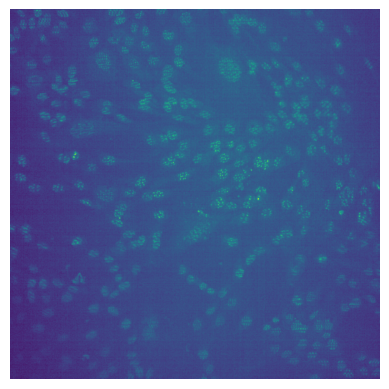

In [23]:

from matplotlib import pyplot as plt
image = np.load('/hpcgpfs01/scratch/xyu1/ch2_3_new_RPE-1_Control_1_Week2/r02c01f02p01-ch3sk1fk1fl1_ch3_nucleus_areas.npy')
plt.imshow(image)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

impath = os.path.join(root_directory, 'r08c12f06p10-ch3sk1fk1fl1_ch3_ori.png')
# Load and display a PNG image
img = mpimg.imread(impath)  # Replace with your actual file path
image_np = np.array(img)

# Normalize the pixel values to [0, 1]
normalized_image = (image_np - image_np.min()) / (image_np.max() - image_np.min())
plt.imshow(normalized_image)
plt.axis('off')